<a href="https://colab.research.google.com/github/ReubenVJose/ReubenVJose.github.io/blob/master/Draft_1_Master_schema_with_4_extracts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# ASSET UNIVERSE MASTER v3 — Final Integration Pipeline
#
# Purpose:
# Combines 4 FDA public data sources into one unified
# pharmaceutical asset database aligned to the Viscadia
# BD&L master schema. Produces a data audit deliverable
# showing what data is available and what gaps remain.
#
# Key improvements over v2:
# 1. Orange Book patent join fixed (integer Appl_No)
# 2. Exclusivity join added (Effective LOE = max of both)
# 3. Two patent columns: Patent_Expiry_Final + Effective_LOE
# 4. Two master sheets: Raw (NDA level) + Consolidated (brand)
# 5. RLD-based brand deduplication (smarter than earliest date)
# 6. Purple Book License_Type used directly for classification
# 7. Purple Book new columns: Center, Dosage_Form, License_Type,
#    Ref. Product Proper Name, Ref. Product Proprietary Name
# 8. Substance_Name restored from openFDA (was incorrectly removed)
# 9. Sheet names fixed to stay under Excel 31-character limit
#
# Input files (upload all 4 to Colab before running):
# 1. Orange_Book_extract_txt_to_xlsx_06_30_2026_v1_0RVJ.xlsx
# 2. purplebook-search-May-data-download__1.xlsx
# 3. openFDA_Core_Extract.xlsx
# 4. DrugsFDA_Master_Final.xlsx
#
# Output: Asset_Universe_Master_v3.xlsx
# Sheet 1: Master_Raw          — NDA level, all columns
# Sheet 2: Master_Consolidated — Brand level, deduplicated
# Sheet 3: Final_Schema        — 19 core schema columns only
# Sheet 4: Coverage_Report     — Data gap analysis
# Sheet 5: Source_Map          — Field lineage documentation
#
# Project: Viscadia Pharma Asset Intelligence Platform
# Author : Reuben Varghese Jose
# Date   : July 2026
# ============================================================


# ============================================================
# BLOCK 1 — IMPORTS
# ============================================================
# What is a library?
# A library is pre-written code someone else built so you
# do not have to write it yourself. Think of it like a
# toolbox — you pick up the tool you need rather than
# manufacturing it from scratch.
#
# pandas      : creates and manipulates data tables called
#               DataFrames. A DataFrame is Python's version
#               of an Excel spreadsheet — rows and columns
#               held in memory.
# numpy       : handles numeric operations and NaN values.
#               NaN = Not a Number = Python's blank cell.
# datetime    : works with dates — needed for LOE calculations.
# openpyxl    : reads and writes Excel .xlsx files.
# PatternFill : sets background color of Excel cells.
# Font        : sets font properties — bold, color, size.
# Alignment   : controls text alignment inside cells.
# get_column_letter : converts a column number to its Excel
#               letter. Column 1 = A, column 27 = AA.
# ============================================================

import subprocess
subprocess.run(["pip", "install", "pandas", "openpyxl", "numpy", "-q"])

import pandas as pd
import numpy as np
from datetime import date
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

print("=" * 70)
print("ASSET UNIVERSE MASTER v3 — Final Integration Pipeline")
print("Viscadia Pharma Asset Intelligence Platform")
print("=" * 70)
print()


# ============================================================
# BLOCK 2 — CONFIGURATION
# ============================================================
# All settings live here at the top of the file.
# This is called separation of configuration from logic.
# If a filename or column name changes, you update it here
# once — not scattered through hundreds of lines of code.
# This is a fundamental software engineering best practice.
# ============================================================

# Input file names — must match exactly what you uploaded
OB_FILE      = "Orange_Book_extract_txt_to_xlsx_06_30_2026_v1_0RVJ.xlsx"
PB_FILE      = "purplebook-search-May-data-download__1.xlsx"
OPENFDA_FILE = "openFDA_Core_Extract.xlsx"
DRUGS_FILE   = "DrugsFDA_Master_Final.xlsx"
OUTPUT_FILE  = "Asset_Universe_Master_v3.xlsx"
PB_SHEET     = "Master PurpleBook May'26"
CURRENT_YEAR = date.today().year

# Valid Drug Classification values from your master schema.
# These are the only values allowed in the Drug Classification
# column — no other values should appear.
VALID_CLASSIFICATIONS = [
    "New Molecular Entity (NME)",
    "Non-NME",
    "Biologic",
    "Biosimilar",
    "Vaccine",
    "Device",
]

# Purple Book License_Type → Drug Classification mapping.
# Option A confirmed: both 351(k) types map to Biosimilar
# in the Drug Classification column. The License_Type column
# preserves the exact FDA category for reference.
LICENSE_TYPE_TO_CLASSIFICATION = {
    "351(a)"               : "Biologic",
    "351(k) Biosimilar"    : "Biosimilar",
    "351(k) Interchangeable": "Biosimilar",
}

# The 16 Therapeutic Category binary flag columns.
# British spelling confirmed from master schema file.
THERAPEUTIC_CATEGORY_FLAGS = [
    "Oncology",
    "Neurology / Psychiatry",
    "Cardiovascular",
    "Metabolic & Endocrine",
    "Respiratory",
    "Immunology",
    "Infectious Diseases / Acute Care",
    "Gastroenterology & Hepatology",
    "Dermatology",
    "Musculoskeletal",
    "Ophthalmology",
    "Hematology",
    "Nephrology / Urology",
    "Vaccines",
    "Gynaecology / Women's Health",
    "Miscellaneous",
]

# The 11 Regulatory Designation binary flag columns.
# Orphan is populated from Drugs@FDA.
# All others require Phase 2 sources.
REGULATORY_FLAGS = [
    "Fast Track",
    "Orphan",
    "SPA",
    "Breakthrough",
    "RMAT",
    "QIDP",
    "CE Marking",
    "Rare Pediatric Disease",
    "Sakigake",
    "PIM",
    "PRIME",
]

# Color scheme for Excel column headers.
# Hex codes represent colors as 6-character strings.
# Format: RRGGBB (Red, Green, Blue each as 2 hex digits).
COLOR_IDENTIFIER  = "1F4E79"  # Dark blue  — identifiers
COLOR_CORE_SCHEMA = "2E75B6"  # Med blue   — 19 core schema fields
COLOR_GAP_FIELDS  = "C00000"  # Dark red   — 0% coverage gaps
COLOR_THERAPEUTIC = "375623"  # Dark green — therapeutic flags
COLOR_REGULATORY  = "7B3F00"  # Dark brown — regulatory flags
COLOR_PATENT      = "7030A0"  # Purple     — patent and LOE columns
COLOR_REFERENCE   = "833C00"  # Dark orange — new reference columns
COLOR_FONT        = "FFFFFF"  # White      — font on all headers

# Column group assignments for color coding
IDENTIFIER_COLS = ["S.No.", "Data Source", "Source_Reference"]

CORE_SCHEMA_COLS = [
    "Drug name", "Other names for product", "MOA", "ROA",
    "Drug Classification", "Orphan Drug", "Final Phase",
    "Marketed/Under Development Flag", "Therapeutic Category",
    "Indications", "Final Launch/Approval Date",
    "Years on market", "Company", "Company Category",
    "Review Priority",
]

PATENT_COLS = ["Patent Expiry Final", "Effective LOE Date"]

GAP_COLS = ["Rare Diseases", "Sub-Therapeutic Category"]

# New reference columns — these appear after the 19 core
# schema columns and before the binary flags.
# They are for analyst reference, not the core deliverable.
REFERENCE_COLS = [
    "License_Type",
    "Center",
    "Dosage_Form",
    "Ref_Product_Name",
    "Ref_Product_Brand",
]

# The exact 19 columns for the Final_Schema deliverable sheet.
# These match the Viscadia master schema specification exactly.
SCHEMA_19_COLS = [
    "S.No.",
    "Data Source",
    "Drug name",
    "Other names for product",
    "MOA",
    "ROA",
    "Drug Classification",
    "Orphan Drug",
    "Rare Diseases",
    "Final Phase",
    "Marketed/Under Development Flag",
    "Therapeutic Category",
    "Sub-Therapeutic Category",
    "Indications",
    "Final Launch/Approval Date",
    "Years on market",
    "Company",
    "Company Category",
    "Patent Expiry Final",
]

# Gap notes for Coverage Report sheet.
# Explains WHY each field is low and WHERE to get the data.
GAP_NOTES = {
    "Rare Diseases"           : "No free public API. Phase 2: FDA Orphan Drug DB + NIH GARD",
    "Sub-Therapeutic Category": "Proprietary Viscadia taxonomy. Phase 2: AI from Indications",
    "Patent Expiry Final"     : "Integer join fixed in v3. ~44.6% for small molecules",
    "Effective LOE Date"      : "Patent + exclusivity join fixed. ~46.7% for small molecules",
    "MOA"                     : "openFDA Pharmacologic_Class_MOA at 4.3% clean. Full text ~70%",
    "Therapeutic Category"    : "openFDA EPC available. Needs mapping to Viscadia taxonomy",
    "Indications"             : "openFDA full text at ~82%. Needs AI cleaning for clean values",
}

PHASE2_SOURCES = {
    "Rare Diseases"           : "FDA Orphan Drug DB + NIH GARD API",
    "Sub-Therapeutic Category": "AI classification via Anthropic API on Indications_Full_Text",
    "Therapeutic Category"    : "ClinicalTrials.gov MeSH terms + NCI Thesaurus mapping",
    "MOA"                     : "AI text extraction via Anthropic API on MOA_Full_Text",
    "Indications"             : "AI text extraction via Anthropic API on Indications_Full_Text",
    "Patent Expiry Final"     : "DrugPatentWatch.com (paid) for remaining ~55% gap",
}

# Source reference documentation for Source_Map sheet.
SOURCE_REFERENCE_MAP = {
    "Drug name": [
        (OB_FILE, "products", "Trade_Name"),
        (PB_FILE, PB_SHEET,   "Drug_Name_Brand"),
    ],
    "Other names for product": [
        (OB_FILE,      "products",     "Ingredient"),
        (PB_FILE,      PB_SHEET,       "Drug_Name_Generic"),
        (OPENFDA_FILE, "openFDA_Core", "Substance_Name"),
    ],
    "MOA": [
        (OPENFDA_FILE, "openFDA_Core", "Pharmacologic_Class_MOA"),
        (OPENFDA_FILE, "openFDA_Core", "MOA_Full_Text"),
    ],
    "ROA": [
        (OB_FILE, "products", "DF;Route (split after semicolon)"),
        (PB_FILE, PB_SHEET,   "ROA"),
    ],
    "Drug Classification": [
        (PB_FILE,    PB_SHEET,          "License_Type (mapped via LICENSE_TYPE_TO_CLASSIFICATION)"),
        (DRUGS_FILE, "DrugsFDA_Master", "Drug_Classification_Label"),
    ],
    "Orphan Drug": [
        (DRUGS_FILE, "DrugsFDA_Master", "Orphan_Drug"),
    ],
    "Final Launch/Approval Date": [
        (DRUGS_FILE, "DrugsFDA_Master", "Approval_Date"),
        (PB_FILE,    PB_SHEET,          "Approval_Date"),
        (OB_FILE,    "products",        "Approval_Date"),
    ],
    "Company": [
        (OB_FILE,    "products",        "Applicant_Full_Name"),
        (PB_FILE,    PB_SHEET,          "Company"),
        (DRUGS_FILE, "DrugsFDA_Master", "SponsorName"),
    ],
    "Patent Expiry Final": [
        (OB_FILE, "patent",  "Patent_Date_Converted (max per Appl_No integer join)"),
        (PB_FILE, PB_SHEET,  "Ref. Product Exclusivity Exp. Date"),
    ],
    "Effective LOE Date": [
        (OB_FILE, "patent",      "Patent_Date_Converted (max)"),
        (OB_FILE, "exclusivity", "Exclusivity_Date_Converted (max)"),
        (PB_FILE, PB_SHEET,      "Ref. Product Exclusivity Exp. Date"),
    ],
    "Therapeutic Category": [
        (OPENFDA_FILE, "openFDA_Core", "Pharmacologic_Class_EPC"),
    ],
    "Indications": [
        (OPENFDA_FILE, "openFDA_Core", "Indications_Full_Text"),
    ],
    "Review Priority": [
        (DRUGS_FILE, "DrugsFDA_Master", "Review_Priority"),
    ],
    "License_Type": [
        (PB_FILE, PB_SHEET, "License_Type"),
    ],
    "Center": [
        (PB_FILE, PB_SHEET, "Center"),
    ],
    "Dosage_Form": [
        (OB_FILE, "products", "DF;Route (part before semicolon)"),
        (PB_FILE, PB_SHEET,   "Dosage_Form"),
    ],
    "Ref_Product_Name": [
        (PB_FILE, PB_SHEET, "Ref. Product Proper Name"),
    ],
    "Ref_Product_Brand": [
        (PB_FILE, PB_SHEET, "Ref. Product Proprietary Name"),
    ],
}


# ============================================================
# BLOCK 3 — HELPER FUNCTIONS
# ============================================================
# A function is a named, reusable block of code.
# We define commonly needed operations as functions once
# and call them whenever needed.
# This is the DRY principle — Don't Repeat Yourself.
# ============================================================

def clean_text(value):
    """
    Converts any value to clean stripped text.
    Returns None for blank, null, dash, nan, or empty values.

    Why needed: Python represents empty in many ways —
    None, NaN, float NaN, empty string "", dash "-".
    This function treats all of them as missing.
    """
    if value is None:
        return None
    if isinstance(value, float) and np.isnan(value):
        return None
    text = str(value).strip()
    return text if text and text.lower() not in (
        "nan", "none", "-", ""
    ) else None


def standardize_key(prefix, number):
    """
    Creates a standardized FDA application number key.
    Format: PREFIX + 6-digit zero-padded number.

    Examples:
    standardize_key("NDA", 205613) → "NDA205613"
    standardize_key("BLA", 101062) → "BLA101062"
    standardize_key("NDA", 4)      → "NDA000004"

    Why zero-pad to 6 digits?
    Different sources store the same application number
    in different formats. Standardizing ensures joins work.
    Note: Orange Book patent joins use raw integers NOT this.
    """
    try:
        return str(prefix) + str(int(float(str(number)))).zfill(6)
    except Exception:
        return None


def split_dosage_form(df_route_value):
    """
    Extracts the Dosage Form from Orange Book DF;Route field.
    Orange Book combines dosage form and ROA in one column:
    "TABLET;ORAL" → Dosage Form = "TABLET", ROA = "ORAL"
    This function extracts the part BEFORE the semicolon.
    """
    val = clean_text(df_route_value)
    if val is None:
        return None
    parts = val.split(";")
    return parts[0].strip()


def split_roa(df_route_value):
    """
    Extracts Route of Administration from Orange Book DF;Route.
    "TABLET;ORAL"    → ROA = "ORAL"
    "INJECTION;IV"   → ROA = "INTRAVENOUS"
    Extracts the part AFTER the semicolon.
    """
    val = clean_text(df_route_value)
    if val is None:
        return None
    parts = val.split(";")
    return parts[-1].strip() if len(parts) > 1 else parts[0].strip()


def clean_date(value):
    """
    Converts any date value to clean YYYY-MM-DD string.
    Removes timestamps (00:00:00).
    Rejects pre-1900 dates — Excel stores time-only values
    as January 1, 1900 which means no real date existed.
    """
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    try:
        ts = pd.to_datetime(value, errors="coerce")
        if pd.isna(ts) or ts.year <= 1900:
            return None
        return ts.strftime("%Y-%m-%d")
    except Exception:
        return None


def calc_years(date_str):
    """
    Calculates years on market from an approval date string.
    Input:  YYYY-MM-DD string or None
    Output: integer years, or "-" if date is missing
    """
    if not date_str:
        return "-"
    try:
        year = int(str(date_str)[:4])
        if year < 1900 or year > CURRENT_YEAR:
            return "-"
        return CURRENT_YEAR - year
    except Exception:
        return "-"


def coalesce(*values):
    """
    Returns the first non-null non-empty value from a list.
    Equivalent to SQL COALESCE().
    Example: coalesce(None, "", "KEYTRUDA") → "KEYTRUDA"
    """
    for v in values:
        cleaned = clean_text(v)
        if cleaned:
            return cleaned
    return "-"


def effective_loe(patent_date, excl_date):
    """
    Returns the effective Loss of Exclusivity date.
    This is the LATER of patent expiry and exclusivity expiry.
    A drug is commercially protected until the LAST protection
    expires. Example: Patent 2028, Exclusivity 2030 → LOE 2030.
    """
    dates = [
        d for d in [patent_date, excl_date]
        if d and clean_text(d) and str(d) not in ("-", "nan", "None")
    ]
    return max(dates) if dates else "-"


def standardize_openfda_key(key):
    """
    Standardizes openFDA Application_No to consistent format.
    Ensures the number part is zero-padded to 6 digits.
    NDA4684   → NDA004684 (padded)
    NDA204684 → NDA204684 (unchanged)
    """
    key = str(key).strip()
    if key.startswith("NDA"):
        return "NDA" + key[3:].zfill(6)
    elif key.startswith("BLA"):
        return "BLA" + key[3:].zfill(6)
    return key


def build_data_source_tag(row):
    """
    Builds a composite Data Source tag showing every source
    that contributed data to this row.

    Examples:
    "Orange Book + Drugs@FDA + openFDA"
    "Purple Book + Drugs@FDA"
    "Purple Book"

    A source is included if it contributed at least one
    non-empty field value to this row.
    """
    sources = []
    foundation = clean_text(row.get("Source_Tag"))
    if foundation:
        sources.append(foundation)
    if clean_text(row.get("Drug_Class_FDA")) or \
       clean_text(row.get("Orphan_Drug_FDA")):
        sources.append("Drugs@FDA")
    if clean_text(row.get("MOA_openFDA")) or \
       clean_text(row.get("MOA_Short")):
        sources.append("openFDA")
    return " + ".join(sources) if sources else "-"


def build_source_reference(row):
    """
    Builds a data lineage string showing exactly which file,
    sheet, and column each field value came from for this row.

    Data lineage means the ability to trace any value back
    to its exact origin. Essential for auditing and debugging.
    """
    parts = []
    src = row.get("Source_Tag", "")

    if clean_text(row.get("Drug_Name")):
        if src == "Orange Book":
            parts.append(f"Drug name → [{OB_FILE} | products | Trade_Name]")
        else:
            parts.append(f"Drug name → [{PB_FILE} | {PB_SHEET} | Drug_Name_Brand]")

    if clean_text(row.get("Generic_Name")):
        if src == "Orange Book":
            parts.append(f"Other Names → [{OB_FILE} | products | Ingredient]")
        else:
            parts.append(f"Other Names → [{PB_FILE} | {PB_SHEET} | Drug_Name_Generic]")

    if clean_text(row.get("Substance_Name_OF")):
        parts.append(f"Other Names (substance) → [{OPENFDA_FILE} | openFDA_Core | Substance_Name]")

    if clean_text(row.get("MOA_Short")):
        parts.append(f"MOA → [{OPENFDA_FILE} | openFDA_Core | Pharmacologic_Class_MOA]")
    elif clean_text(row.get("MOA_openFDA")):
        parts.append(f"MOA → [{OPENFDA_FILE} | openFDA_Core | MOA_Full_Text]")

    if clean_text(row.get("ROA_Clean")):
        if src == "Orange Book":
            parts.append(f"ROA → [{OB_FILE} | products | DF;Route (after semicolon)]")
        else:
            parts.append(f"ROA → [{PB_FILE} | {PB_SHEET} | ROA]")

    if clean_text(row.get("License_Type_PB")):
        parts.append(f"Drug Classification → [{PB_FILE} | {PB_SHEET} | License_Type]")
    elif clean_text(row.get("Drug_Class_FDA")):
        parts.append(f"Drug Classification → [{DRUGS_FILE} | DrugsFDA_Master | Drug_Classification_Label]")
    else:
        parts.append(f"Drug Classification → [Derived from Source_Tag]")

    if clean_text(row.get("Orphan_Drug_FDA")):
        parts.append(f"Orphan Drug → [{DRUGS_FILE} | DrugsFDA_Master | Orphan_Drug]")

    if clean_text(row.get("Appr_Date_FDA")):
        parts.append(f"Approval Date → [{DRUGS_FILE} | DrugsFDA_Master | Approval_Date]")
    elif clean_text(row.get("Appr_Date_PB")):
        parts.append(f"Approval Date → [{PB_FILE} | {PB_SHEET} | Approval_Date]")
    elif clean_text(row.get("Appr_Date_OB")):
        parts.append(f"Approval Date → [{OB_FILE} | products | Approval_Date]")

    if clean_text(row.get("Company_Clean")):
        if src == "Orange Book":
            parts.append(f"Company → [{OB_FILE} | products | Applicant_Full_Name]")
        else:
            parts.append(f"Company → [{PB_FILE} | {PB_SHEET} | Company]")
    elif clean_text(row.get("Sponsor_FDA")):
        parts.append(f"Company → [{DRUGS_FILE} | DrugsFDA_Master | SponsorName]")

    pat = row.get("Patent_Expiry_OB")
    if pat and str(pat) not in ("-", "nan", "None") and pd.notna(pat):
        parts.append(f"Patent Expiry → [{OB_FILE} | patent | Patent_Date_Converted]")
    elif clean_text(row.get("Patent_Expiry_PB")):
        parts.append(f"Patent Expiry → [{PB_FILE} | {PB_SHEET} | Ref. Product Exclusivity Exp. Date]")

    excl = row.get("Excl_Expiry_OB")
    if excl and str(excl) not in ("-", "nan", "None") and pd.notna(excl):
        parts.append(f"Exclusivity Expiry → [{OB_FILE} | exclusivity | Exclusivity_Date_Converted]")

    if clean_text(row.get("Therapeutic_EPC")):
        parts.append(f"Therapeutic Category → [{OPENFDA_FILE} | openFDA_Core | Pharmacologic_Class_EPC]")

    if clean_text(row.get("Indications_openFDA")):
        parts.append(f"Indications → [{OPENFDA_FILE} | openFDA_Core | Indications_Full_Text]")

    if clean_text(row.get("Review_Priority_FDA")):
        parts.append(f"Review Priority → [{DRUGS_FILE} | DrugsFDA_Master | Review_Priority]")

    return " | ".join(parts) if parts else "-"


print("All helper functions defined.")
print()


# ============================================================
# BLOCK 4 — LOAD ALL SOURCE FILES
# ============================================================
# We load all source files upfront before any processing.
# Loading upfront means:
# 1. File-not-found errors appear immediately
# 2. All data is in memory for fast processing
# 3. We read each file exactly once
#
# After loading Purple Book we strip trailing spaces from
# column names. The Purple Book has 'Years_on_Market ' with
# a trailing space. If not stripped, any code referencing
# 'Years_on_Market' without the space throws a KeyError.
# .columns.str.strip() removes leading and trailing whitespace
# from every column name in the DataFrame.
# ============================================================

print("BLOCK 4 — Loading all source files...")

ob_all     = pd.read_excel(OB_FILE, sheet_name="products")
ob_patents = pd.read_excel(OB_FILE, sheet_name="patent")
ob_excl    = pd.read_excel(OB_FILE, sheet_name="exclusivity")
pb_all     = pd.read_excel(PB_FILE, sheet_name=PB_SHEET)
openfda    = pd.read_excel(OPENFDA_FILE)
drugs      = pd.read_excel(DRUGS_FILE)

# Strip trailing spaces from Purple Book column names
pb_all.columns = pb_all.columns.str.strip()

print(f"  Orange Book products   : {len(ob_all):,} rows")
print(f"  Orange Book patents    : {len(ob_patents):,} rows")
print(f"  Orange Book exclusivity: {len(ob_excl):,} rows")
print(f"  Purple Book            : {len(pb_all):,} rows")
print(f"  openFDA Core           : {len(openfda):,} rows")
print(f"  Drugs@FDA Master       : {len(drugs):,} rows")
print()

# Verify key column names before proceeding.
# This catches column name mismatches early rather than
# letting them cause silent failures deeper in the pipeline.
checks = [
    (ob_all,     "Trade_Name",         "OB products"),
    (ob_all,     "Appl_No",            "OB products"),
    (ob_all,     "RLD",                "OB products"),
    (ob_patents, "Patent_Date_Converted", "OB patent"),
    (ob_excl,    "Exclusivity_Date_Converted", "OB exclusivity"),
    (pb_all,     "Drug_Name_Brand",    "Purple Book"),
    (pb_all,     "License_Type",       "Purple Book"),
    (pb_all,     "Center",             "Purple Book"),
    (pb_all,     "Dosage_Form",        "Purple Book"),
    (pb_all,     "Years_on_Market",    "Purple Book"),
    (pb_all,     "Ref. Product Proper Name", "Purple Book"),
    (pb_all,     "Ref. Product Proprietary Name", "Purple Book"),
    (openfda,    "Application_No",     "openFDA"),
    (openfda,    "Substance_Name",     "openFDA"),
    (openfda,    "Pharmacologic_Class_MOA", "openFDA"),
    (drugs,      "ApplNo",             "Drugs@FDA"),
    (drugs,      "Orphan_Drug",        "Drugs@FDA"),
]
print("Verifying key columns exist...")
for df_check, col, label in checks:
    if col not in df_check.columns:
        print(f"  WARNING — {label}: column '{col}' NOT FOUND")
    else:
        print(f"  OK — {label}: {col}")
print()


# ============================================================
# BLOCK 5 — PREPARE ORANGE BOOK CORE (TWO DEDUP LEVELS)
# ============================================================
# Filter Orange Book to BD&L relevant drugs:
# Appl_Type = N → innovator branded drug (has original IP)
# Type = RX     → currently marketed prescription drug
#
# TWO DEDUPLICATION LEVELS:
#
# Level 1 — NDA level
# One NDA can have multiple products (100mg, 200mg, 400mg).
# We keep one row per NDA application.
# Used for the Master_Raw sheet.
#
# Level 2 — Brand name level
# One brand name can have multiple NDAs across different eras.
# Example: DEPAKOTE approved in 1983 AND 1989 = two NDAs
# but ONE commercial asset for BD&L purposes.
#
# NEW IN V3: RLD-based canonical selection.
# When the same brand name appears under multiple NDAs, we
# keep the row where RLD = Yes (Reference Listed Drug).
# RLD = Yes means FDA designated this as the primary
# reference product — more defensible than earliest date.
# If no row has RLD = Yes, we fall back to earliest date.
#
# For ROA: concatenate all unique values with semicolon.
# UCERIS RECTAL + UCERIS ORAL → ROA = "ORAL; RECTAL"
# ============================================================

print("BLOCK 5 — Preparing Orange Book Core (two dedup levels)...")

ob_core = ob_all[
    (ob_all["Appl_Type"] == "N") &
    (ob_all["Type"] == "RX")
].copy()

ob_core["Std_Key"]        = ob_core.apply(
    lambda r: standardize_key("NDA", r["Appl_No"]), axis=1
)
ob_core["Drug_Name"]      = ob_core["Trade_Name"].apply(clean_text)
ob_core["Generic_Name"]   = ob_core["Ingredient"].apply(clean_text)
ob_core["ROA_Clean"]      = ob_core["DF;Route"].apply(split_roa)
ob_core["Dosage_Form_OB"] = ob_core["DF;Route"].apply(split_dosage_form)
ob_core["Company_Clean"]  = ob_core["Applicant_Full_Name"].apply(clean_text)
ob_core["Appr_Date_OB"]   = ob_core["Approval_Date"].apply(clean_date)
ob_core["RLD_Flag"]        = ob_core["RLD"].apply(clean_text)
ob_core["Source_Tag"]      = "Orange Book"

print(f"  OB raw (N + RX)        : {len(ob_core):,}")

# --- Level 1: NDA deduplication ---
# Keep first product per NDA application.
ob_nda_deduped = ob_core.drop_duplicates(
    subset=["Std_Key"], keep="first"
)[[
    "Std_Key", "Appl_No", "Drug_Name", "Generic_Name",
    "ROA_Clean", "Dosage_Form_OB", "Company_Clean",
    "Appr_Date_OB", "RLD_Flag", "Source_Tag"
]].copy()

print(f"  After NDA dedup        : {len(ob_nda_deduped):,}")

# --- Level 2: Brand name deduplication ---
# Step 1: Sort so RLD=Yes rows come first, then by approval date.
# This means when we drop duplicates keeping "first", the
# RLD=Yes row will be kept as the canonical record.
ob_nda_deduped["RLD_Sort"] = ob_nda_deduped["RLD_Flag"].apply(
    lambda x: 0 if x == "Yes" else 1
)
ob_nda_deduped["Appr_Sort"] = pd.to_datetime(
    ob_nda_deduped["Appr_Date_OB"], errors="coerce"
)
ob_nda_sorted = ob_nda_deduped.sort_values(
    ["Drug_Name", "RLD_Sort", "Appr_Sort"],
    ascending=[True, True, True]
)

# Step 2: Aggregate ROA — collect all unique ROA values
# per brand name and join with semicolon.
roa_agg = ob_nda_sorted.groupby("Drug_Name")["ROA_Clean"].apply(
    lambda x: "; ".join(
        sorted(set(v for v in x if v and v not in ("-", "nan", "None")))
    )
).reset_index()
roa_agg.columns = ["Drug_Name", "ROA_Combined"]

# Step 3: Keep first occurrence per brand name.
# After sorting RLD=Yes first, this keeps the canonical row.
ob_brand_deduped = ob_nda_sorted.drop_duplicates(
    subset=["Drug_Name"], keep="first"
)[[
    "Std_Key", "Appl_No", "Drug_Name", "Generic_Name",
    "Dosage_Form_OB", "Company_Clean", "Appr_Date_OB", "Source_Tag"
]].copy()

# Step 4: Join the combined ROA back.
ob_brand_deduped = ob_brand_deduped.merge(
    roa_agg, on="Drug_Name", how="left"
)
ob_brand_deduped["ROA_Clean"] = ob_brand_deduped["ROA_Combined"].fillna("-")
ob_brand_deduped = ob_brand_deduped.drop(columns=["ROA_Combined"])

print(f"  After brand dedup      : {len(ob_brand_deduped):,}")
print(f"  Brand duplicates removed: {len(ob_nda_deduped) - len(ob_brand_deduped):,}")
print()


# ============================================================
# BLOCK 6 — ORANGE BOOK PATENT AND EXCLUSIVITY (FIXED JOIN)
# ============================================================
# KEY FIX: Join on raw INTEGER Appl_No, NOT string keys.
#
# Why the string key join was broken:
# Products sheet has 6-digit modern numbers (215328).
# Patent sheet has 5-digit older numbers (20610).
# These are different applications from different FDA eras.
# Building string keys like "NDA020610" and "NDA215328"
# and comparing them gives ZERO matches because they are
# genuinely different application numbers.
#
# The fix: join on the raw integer Appl_No directly.
# Integer 20610 matches integer 20610 perfectly.
# No prefix, no padding, no string formatting.
#
# This gives: ~1,081 patent matches (44.6% of OB Core)
#             ~517 exclusivity matches (21.3% of OB Core)
#             ~1,131 effective LOE dates (46.7% of OB Core)
# ============================================================

print("BLOCK 6 — Preparing Orange Book patent and exclusivity (FIXED)...")

ob_patents["Patent_Date"] = pd.to_datetime(
    ob_patents["Patent_Date_Converted"], errors="coerce"
)
patent_max = ob_patents.groupby("Appl_No")["Patent_Date"].max().reset_index()
patent_max.columns = ["Appl_No", "Patent_Date_Max"]
patent_max["Patent_Expiry_OB"] = (
    patent_max["Patent_Date_Max"].dt.strftime("%Y-%m-%d")
)
patent_max = patent_max[
    patent_max["Patent_Expiry_OB"].notna()
][["Appl_No", "Patent_Expiry_OB"]]

ob_excl["Excl_Date"] = pd.to_datetime(
    ob_excl["Exclusivity_Date_Converted"], errors="coerce"
)
excl_max = ob_excl.groupby("Appl_No")["Excl_Date"].max().reset_index()
excl_max.columns = ["Appl_No", "Excl_Date_Max"]
excl_max["Excl_Expiry_OB"] = (
    excl_max["Excl_Date_Max"].dt.strftime("%Y-%m-%d")
)
excl_max = excl_max[
    excl_max["Excl_Expiry_OB"].notna()
][["Appl_No", "Excl_Expiry_OB"]]

ob_appl_nos    = set(ob_nda_deduped["Appl_No"])
pat_matches    = len(ob_appl_nos.intersection(set(patent_max["Appl_No"])))
excl_matches   = len(ob_appl_nos.intersection(set(excl_max["Appl_No"])))

print(f"  Patent records with valid date    : {len(patent_max):,}")
print(f"  Exclusivity records with valid date: {len(excl_max):,}")
print(f"  Expected patent matches (NDA)     : {pat_matches:,}")
print(f"  Expected excl matches (NDA)       : {excl_matches:,}")
print()


# ============================================================
# BLOCK 7 — PREPARE PURPLE BOOK CORE (NEW FIELDS ADDED)
# ============================================================
# Filter to Marketing_Status = Rx (currently marketed).
# Deduplicate to one row per unique BLA application.
#
# NEW IN V3: Additional columns extracted from Purple Book.
# License_Type → used directly for Drug Classification.
# Center → CDER or CBER (therapeutic vs vaccine/blood).
# Dosage_Form → physical form of the drug.
# Ref. Product Proper Name → reference biologic generic name.
# Ref. Product Proprietary Name → reference biologic brand.
# Years_on_Market → used directly for biologics instead of
#                   deriving from approval date calculation.
#
# Drug Classification logic using License_Type:
# 351(a)                → Biologic
# 351(k) Biosimilar     → Biosimilar
# 351(k) Interchangeable → Biosimilar  (Option A confirmed)
# The License_Type column is kept separately so you can
# always distinguish 351(k) Biosimilar from 351(k) Inter.
# ============================================================

print("BLOCK 7 — Preparing Purple Book Core (with new fields)...")

pb_core = pb_all[pb_all["Marketing_Status"] == "Rx"].copy()

pb_core["Std_Key"] = pb_core["BLA_No"].apply(
    lambda x: standardize_key("BLA", x)
)
pb_core["Appr_Date_PB"] = pb_core["Approval_Date"].apply(clean_date)

pb_core["Patent_Expiry_PB"] = pb_core.apply(
    lambda r: clean_date(r.get("Ref. Product Exclusivity Exp. Date"))
              or clean_date(r.get("Orphan_Exclusivity_Date")),
    axis=1
)

# Map License_Type directly to Drug Classification
pb_core["Drug_Class_PB"] = pb_core["License_Type"].map(
    LICENSE_TYPE_TO_CLASSIFICATION
)

# Clean reference product columns
pb_core["Ref_Product_Name_PB"]  = pb_core["Ref. Product Proper Name"].apply(clean_text)
pb_core["Ref_Product_Brand_PB"] = pb_core["Ref. Product Proprietary Name"].apply(clean_text)

# Deduplicate — one row per BLA application
pb_deduped = pb_core.drop_duplicates(
    subset=["Std_Key"], keep="first"
)[[
    "Std_Key", "Drug_Name_Brand", "Drug_Name_Generic",
    "ROA", "Company", "Appr_Date_PB",
    "Drug_Class_PB", "Patent_Expiry_PB",
    "License_Type", "Center", "Dosage_Form",
    "Years_on_Market",
    "Ref_Product_Name_PB", "Ref_Product_Brand_PB",
]].copy()

pb_deduped = pb_deduped.rename(columns={
    "Drug_Name_Brand" : "Drug_Name",
    "Drug_Name_Generic": "Generic_Name",
    "ROA"             : "ROA_Clean",
    "Company"         : "Company_Clean",
    "License_Type"    : "License_Type_PB",
    "Center"          : "Center_PB",
    "Dosage_Form"     : "Dosage_Form_PB",
    "Years_on_Market" : "Years_on_Market_PB",
})
pb_deduped["Dosage_Form_OB"] = None  # OB field — not available for PB rows
pb_deduped["Source_Tag"]     = "Purple Book"
pb_deduped["Appl_No"]        = pd.to_numeric(
    pb_deduped["Std_Key"].str.replace("BLA", ""), errors="coerce"
)

print(f"  PB raw (Rx marketed)   : {len(pb_core):,}")
print(f"  After BLA dedup        : {len(pb_deduped):,}")
print()

# Show License_Type breakdown in PB core
lt_breakdown = pb_core.drop_duplicates(subset=["Std_Key"])["License_Type"].value_counts()
print("  License_Type breakdown (unique BLAs):")
for lt, cnt in lt_breakdown.items():
    mapped = LICENSE_TYPE_TO_CLASSIFICATION.get(lt, "Unknown")
    print(f"    {lt:<30} : {cnt:>4} → Drug Classification = {mapped}")
print()


# ============================================================
# BLOCK 8 — BUILD BOTH ASSET BASES
# ============================================================
# Two asset bases — same logic, different OB dedup level.
#
# asset_base_raw:  NDA level OB + BLA level PB
#                  Used for Master_Raw sheet.
#
# asset_base_cons: Brand level OB + BLA level PB
#                  Used for Master_Consolidated sheet.
#
# pd.concat() stacks rows vertically — this is called a UNION.
# A UNION adds rows from two tables into one combined table.
# ignore_index=True resets row numbers after stacking.
# sort=False keeps columns in their original order.
# ============================================================

print("BLOCK 8 — Building both Asset Bases...")

asset_base_raw  = pd.concat(
    [ob_nda_deduped, pb_deduped], ignore_index=True, sort=False
)
asset_base_cons = pd.concat(
    [ob_brand_deduped, pb_deduped], ignore_index=True, sort=False
)

print(f"  OB NDA level           : {len(ob_nda_deduped):,}")
print(f"  OB Brand level         : {len(ob_brand_deduped):,}")
print(f"  PB BLA level           : {len(pb_deduped):,}")
print(f"  Asset Base RAW         : {len(asset_base_raw):,} rows")
print(f"  Asset Base CONSOLIDATED: {len(asset_base_cons):,} rows")
print()


# ============================================================
# BLOCK 9 — PREPARE DRUGS@FDA ENRICHMENT
# ============================================================
# Drugs@FDA adds four critical fields unavailable elsewhere:
# 1. Drug_Classification_Label — NME, Non-NME, Biologic etc.
# 2. Orphan_Drug — YES or NO with 100% coverage
# 3. Approval_Date — real original FDA approval date
# 4. Review_Priority — Standard, Priority, Breakthrough
#
# This is a LEFT JOIN enrichment — adds columns to existing
# rows without removing any rows from the Asset Base.
# ============================================================

print("BLOCK 9 — Preparing Drugs@FDA enrichment...")

drugs["Std_Key"] = drugs.apply(
    lambda r: standardize_key(r["ApplType"], r["ApplNo"]), axis=1
)

drugs_enrich = drugs[[
    "Std_Key", "Drug_Classification_Label", "Orphan_Drug",
    "Approval_Date", "SponsorName", "Marketing_Status",
    "Review_Priority"
]].drop_duplicates(subset=["Std_Key"], keep="first").rename(columns={
    "Drug_Classification_Label" : "Drug_Class_FDA",
    "Orphan_Drug"               : "Orphan_Drug_FDA",
    "Approval_Date"             : "Appr_Date_FDA",
    "SponsorName"               : "Sponsor_FDA",
    "Marketing_Status"          : "Marketing_Status_FDA",
    "Review_Priority"           : "Review_Priority_FDA",
})

matched = len(
    set(asset_base_cons["Std_Key"]).intersection(set(drugs_enrich["Std_Key"]))
)
print(f"  Drugs@FDA enrichment rows        : {len(drugs_enrich):,}")
print(f"  Consolidated drugs with FDA match: {matched:,}/{len(asset_base_cons):,}")
print()


# ============================================================
# BLOCK 10 — PREPARE openFDA ENRICHMENT (SUBSTANCE_NAME RESTORED)
# ============================================================
# openFDA adds MOA, Indications, and Pharmacologic Class.
#
# FIX IN V3: Substance_Name restored.
# This column was incorrectly removed in v2. It exists in
# openFDA_Core_Extract.xlsx at 95% coverage and provides
# the chemical substance name as an additional alias for
# the Other Names schema field.
# ============================================================

print("BLOCK 10 — Preparing openFDA enrichment (Substance_Name restored)...")

openfda["Std_Key"] = openfda["Application_No"].apply(
    standardize_openfda_key
)

openfda_enrich = openfda[[
    "Std_Key",
    "MOA_Full_Text",
    "Indications_Full_Text",
    "Pharmacologic_Class_EPC",
    "Pharmacologic_Class_MOA",
    "Substance_Name",           # Restored in v3
    "RxCUI",
]].drop_duplicates(subset=["Std_Key"], keep="first").rename(columns={
    "MOA_Full_Text"           : "MOA_openFDA",
    "Indications_Full_Text"   : "Indications_openFDA",
    "Pharmacologic_Class_EPC" : "Therapeutic_EPC",
    "Pharmacologic_Class_MOA" : "MOA_Short",
    "Substance_Name"          : "Substance_Name_OF",
})

matched_of = len(
    set(asset_base_cons["Std_Key"]).intersection(set(openfda_enrich["Std_Key"]))
)
print(f"  openFDA enrichment rows          : {len(openfda_enrich):,}")
print(f"  Consolidated drugs with openFDA  : {matched_of:,}/{len(asset_base_cons):,}")
print()


# ============================================================
# BLOCK 11 — JOIN ALL SOURCES TO BOTH ASSET BASES
# ============================================================
# Four LEFT JOINs applied to both asset bases:
#
# Join 1 — Drugs@FDA (on Std_Key string join)
# Join 2 — openFDA   (on Std_Key string join)
# Join 3 — OB Patent (on raw INTEGER Appl_No — FIXED)
# Join 4 — OB Exclusivity (on raw INTEGER Appl_No — FIXED)
#
# What is a LEFT JOIN?
# Keeps ALL rows from the left table (Asset Base) and adds
# matching columns from the right table. Rows with no match
# get null values in the added columns — they are never
# removed. No drug ever disappears from our universe.
#
# We apply the same 4 joins to both RAW and CONSOLIDATED
# bases using a helper function to avoid repeating code.
# ============================================================

print("BLOCK 11 — Joining all enrichment sources to both Asset Bases...")


def enrich_asset_base(base_df, label):
    """
    Applies all 4 enrichment joins to a given asset base.
    Used for both RAW and CONSOLIDATED bases.
    """
    df = base_df.copy()

    # Join 1 — Drugs@FDA (string Std_Key join)
    df = df.merge(drugs_enrich, on="Std_Key", how="left")

    # Join 2 — openFDA (string Std_Key join)
    df = df.merge(openfda_enrich, on="Std_Key", how="left")

    # Extract numeric Appl_No from Std_Key for integer joins.
    # Std_Key = "NDA215328" → we need just 215328 as integer.
    # str.replace removes the prefix, pd.to_numeric converts
    # to number, astype("Int64") makes it a nullable integer
    # (capital I allows null values unlike regular int).
    df["Appl_No_Int"] = pd.to_numeric(
        df["Std_Key"].str.replace("NDA", "").str.replace("BLA", ""),
        errors="coerce"
    ).astype("Int64")

    # Join 3 — OB Patent (raw integer Appl_No join)
    df = df.merge(
        patent_max, left_on="Appl_No_Int", right_on="Appl_No", how="left"
    )
    df = df.drop(columns=["Appl_No"], errors="ignore")

    # Join 4 — OB Exclusivity (raw integer Appl_No join)
    df = df.merge(
        excl_max, left_on="Appl_No_Int", right_on="Appl_No", how="left"
    )
    df = df.drop(columns=["Appl_No"], errors="ignore")

    print(f"  {label} after all joins : {len(df):,} rows (no rows lost)")
    return df


master_raw  = enrich_asset_base(asset_base_raw,  "RAW ")
master_cons = enrich_asset_base(asset_base_cons, "CONS")
print()


# ============================================================
# BLOCK 12 — BUILD FINAL SCHEMA COLUMNS
# ============================================================
# Apply business logic to produce all final output columns.
#
# COALESCE pattern — for each field we define priority order:
# which source to use first, which to fall back to.
# coalesce() returns the first non-null non-empty value.
#
# KEY UPDATES IN V3:
# Other Names: Generic_Name → Substance_Name (from openFDA)
# Drug Classification for PB: License_Type_PB used directly
# Years on Market for PB: use pre-calculated Years_on_Market_PB
# Two patent columns: Patent_Expiry_Final + Effective_LOE_Date
# Three new reference columns: License_Type, Center, Dosage_Form
# ============================================================

print("BLOCK 12 — Building final schema columns...")


def determine_classification(row):
    """
    Drug Classification priority:
    1. Purple Book License_Type (most precise for biologics)
    2. Drugs@FDA label (NME, Non-NME for small molecules)
    3. Source fallback (OB → Non-NME, PB → Biologic)
    """
    pb_class  = clean_text(row.get("Drug_Class_PB"))
    fda_class = clean_text(row.get("Drug_Class_FDA"))
    src       = clean_text(row.get("Source_Tag", ""))

    # Priority 1: Purple Book License_Type (already mapped)
    if pb_class and pb_class in VALID_CLASSIFICATIONS:
        return pb_class
    # Priority 2: Drugs@FDA classification
    if fda_class and fda_class in VALID_CLASSIFICATIONS:
        return fda_class
    # Priority 3: Source fallback
    if src == "Orange Book":
        return "Non-NME"
    if src == "Purple Book":
        return "Biologic"
    return "-"


def build_final_columns(master, label):
    """
    Builds all final schema and reference columns for one
    master DataFrame. Applied to both RAW and CONSOLIDATED.
    """

    # Company — OB/PB Company → Drugs@FDA Sponsor
    master["Final_Company"] = master.apply(
        lambda r: coalesce(r.get("Company_Clean"), r.get("Sponsor_FDA")),
        axis=1
    )

    # Company Category — Single vs Multi asset.
    # Counts how many drugs each company has in the database.
    company_counts = master["Final_Company"].value_counts().to_dict()
    master["Final_Company_Cat"] = master["Final_Company"].apply(
        lambda x: "Single-asset company" if company_counts.get(x, 0) == 1
        else "Multi-asset company" if company_counts.get(x, 0) > 1
        else "-"
    )

    # Approval Date — Drugs@FDA → PB → OB
    master["Final_Approval_Date"] = master.apply(
        lambda r: coalesce(
            r.get("Appr_Date_FDA"),
            r.get("Appr_Date_PB"),
            r.get("Appr_Date_OB")
        ), axis=1
    )

    # Years on Market.
    # For Purple Book rows: use pre-calculated Years_on_Market_PB
    # if available. This is more reliable when approval dates
    # are missing from the Drugs@FDA lookup.
    # For all other rows: derive from approval date.
    def calc_years_on_market(row):
        pb_years = row.get("Years_on_Market_PB")
        if row.get("Source_Tag") == "Purple Book" and \
           pb_years and pd.notna(pb_years):
            try:
                return int(pb_years)
            except Exception:
                pass
        return calc_years(row.get("Final_Approval_Date"))

    master["Final_Years"] = master.apply(calc_years_on_market, axis=1)

    # Patent Expiry Final — OB patent for small molecules,
    # PB exclusivity proxy for biologics.
    master["Final_Patent_Expiry"] = master.apply(
        lambda r: coalesce(
            r.get("Patent_Expiry_OB"),
            r.get("Patent_Expiry_PB")
        ), axis=1
    )

    # Effective LOE Date — LATER of patent + exclusivity.
    # For OB rows: MAX(Patent_Expiry_OB, Excl_Expiry_OB).
    # For PB rows: best available exclusivity proxy.
    master["Final_Effective_LOE"] = master.apply(
        lambda r: effective_loe(
            r.get("Patent_Expiry_OB"),
            r.get("Excl_Expiry_OB")
        ) if r.get("Source_Tag") == "Orange Book"
        else coalesce(r.get("Patent_Expiry_PB")),
        axis=1
    )

    # All remaining schema fields
    master["Final_SNo"]           = range(1, len(master) + 1)
    master["Final_Drug_Name"]     = master.apply(
        lambda r: coalesce(r.get("Drug_Name")), axis=1
    )

    # Other Names — Generic_Name first, then Substance_Name
    # (restored from openFDA in Block 10 of this v3 pipeline)
    master["Final_Other_Names"]   = master.apply(
        lambda r: coalesce(
            r.get("Generic_Name"),
            r.get("Substance_Name_OF")
        ), axis=1
    )

    master["Final_MOA"]           = master.apply(
        lambda r: coalesce(r.get("MOA_Short"), r.get("MOA_openFDA")),
        axis=1
    )
    master["Final_ROA"]           = master.apply(
        lambda r: coalesce(r.get("ROA_Clean")), axis=1
    )
    master["Final_Classification"] = master.apply(
        determine_classification, axis=1
    )
    master["Final_Orphan_Drug"]   = master.apply(
        lambda r: coalesce(r.get("Orphan_Drug_FDA"), "NO"), axis=1
    )
    master["Final_Rare_Diseases"] = "-"
    master["Final_Phase"]         = "Marketed"
    master["Final_Marketed_Flag"] = "Marketed"
    master["Final_Therapeutic"]   = master.apply(
        lambda r: coalesce(r.get("Therapeutic_EPC")), axis=1
    )
    master["Final_Sub_Ther"]      = "-"
    master["Final_Indications"]   = master.apply(
        lambda r: coalesce(r.get("Indications_openFDA")), axis=1
    )
    master["Final_Review_Prio"]   = master.apply(
        lambda r: coalesce(r.get("Review_Priority_FDA")), axis=1
    )

    # Reference columns — from Purple Book, OB dash for non-PB rows
    # License_Type: exact FDA biologic category.
    # Purple Book rows get 351(a), 351(k) Biosimilar, or
    # 351(k) Interchangeable. Orange Book rows get dash.
    master["Final_License_Type"]  = master.apply(
        lambda r: coalesce(r.get("License_Type_PB")), axis=1
    )
    master["Final_Center"]        = master.apply(
        lambda r: coalesce(r.get("Center_PB")), axis=1
    )
    # Dosage Form: OB rows use the part before semicolon in DF;Route.
    # PB rows use the Dosage_Form column directly.
    master["Final_Dosage_Form"]   = master.apply(
        lambda r: coalesce(
            r.get("Dosage_Form_PB"),
            r.get("Dosage_Form_OB")
        ), axis=1
    )
    master["Final_Ref_Product"]   = master.apply(
        lambda r: coalesce(r.get("Ref_Product_Name_PB")), axis=1
    )
    master["Final_Ref_Brand"]     = master.apply(
        lambda r: coalesce(r.get("Ref_Product_Brand_PB")), axis=1
    )

    print(f"  {label} — all schema fields built.")
    return master


master_raw  = build_final_columns(master_raw,  "RAW ")
master_cons = build_final_columns(master_cons, "CONS")
print()


# ============================================================
# BLOCK 13 — BUILD BINARY FLAG COLUMNS
# ============================================================
# 27 binary flag columns — each is 0 or 1.
# 0 means this flag does not apply to this drug.
# 1 means this flag applies.
#
# Orphan flag: populated from Drugs@FDA (YES → 1).
# All other flags: 0 for MVP.
# Phase 2 will populate from FDA designation databases
# and ClinicalTrials.gov.
#
# Why 0 and 1 instead of Yes/No?
# Binary integers are faster to filter and sum.
# =SUM(Oncology) counts all oncology drugs directly.
# With Yes/No you would need COUNTIF instead.
# ============================================================

print("BLOCK 13 — Building binary flag columns...")


def build_flags(master):
    for flag in THERAPEUTIC_CATEGORY_FLAGS:
        master[flag] = 0
    master["Orphan"] = master["Final_Orphan_Drug"].apply(
        lambda x: 1 if str(x).upper() == "YES" else 0
    )
    for flag in REGULATORY_FLAGS:
        if flag != "Orphan":
            master[flag] = 0
    return master


master_raw  = build_flags(master_raw)
master_cons = build_flags(master_cons)

print(f"  Orphan = 1 : {master_cons['Orphan'].sum():,} drugs (Consolidated)")
print(f"  All therapeutic flags : 0 (Phase 2)")
print(f"  All other regulatory flags : 0 (Phase 2)")
print()


# ============================================================
# BLOCK 14 — ASSEMBLE FINAL OUTPUT DATAFRAMES
# ============================================================
# Select, rename, and order all columns into the final output.
#
# Column order:
# 1. S.No. and Data Source (identifiers)
# 2. 19 core schema columns
# 3. Review Priority (additional schema-relevant field)
# 4. Patent Expiry Final and Effective LOE Date (purple)
# 5. Reference columns: License_Type, Center, Dosage_Form,
#    Ref_Product_Name, Ref_Product_Brand (dark orange)
# 6. 16 Therapeutic Category flags (dark green)
# 7. 11 Regulatory Designation flags (dark brown)
# 8. Source_Reference for data lineage (dark blue)
# ============================================================

print("BLOCK 14 — Assembling final output DataFrames...")


def assemble_final(master, label):
    final = pd.DataFrame()

    # Identifiers
    final["S.No."]                           = master["Final_SNo"]
    final["Data Source"]                     = master.apply(
        build_data_source_tag, axis=1
    )

    # 19 core schema columns
    final["Drug name"]                       = master["Final_Drug_Name"]
    final["Other names for product"]         = master["Final_Other_Names"]
    final["MOA"]                             = master["Final_MOA"]
    final["ROA"]                             = master["Final_ROA"]
    final["Drug Classification"]             = master["Final_Classification"]
    final["Orphan Drug"]                     = master["Final_Orphan_Drug"]
    final["Rare Diseases"]                   = master["Final_Rare_Diseases"]
    final["Final Phase"]                     = master["Final_Phase"]
    final["Marketed/Under Development Flag"] = master["Final_Marketed_Flag"]
    final["Therapeutic Category"]            = master["Final_Therapeutic"]
    final["Sub-Therapeutic Category"]        = master["Final_Sub_Ther"]
    final["Indications"]                     = master["Final_Indications"]
    final["Final Launch/Approval Date"]      = master["Final_Approval_Date"]
    final["Years on market"]                 = master["Final_Years"]
    final["Company"]                         = master["Final_Company"]
    final["Company Category"]                = master["Final_Company_Cat"]
    final["Patent Expiry Final"]             = master["Final_Patent_Expiry"]

    # Additional schema-relevant columns
    final["Review Priority"]                 = master["Final_Review_Prio"]
    final["Effective LOE Date"]              = master["Final_Effective_LOE"]

    # Reference columns — biologic-specific fields
    # Orange Book rows will show dash for these columns.
    # This is correct — they are Purple Book fields.
    final["License_Type"]      = master["Final_License_Type"]
    final["Center"]            = master["Final_Center"]
    final["Dosage_Form"]       = master["Final_Dosage_Form"]
    final["Ref_Product_Name"]  = master["Final_Ref_Product"]
    final["Ref_Product_Brand"] = master["Final_Ref_Brand"]

    # 27 binary flag columns
    for flag in THERAPEUTIC_CATEGORY_FLAGS + REGULATORY_FLAGS:
        final[flag] = master[flag]

    # Source reference — data lineage for debugging
    final["Source_Reference"] = master.apply(
        build_source_reference, axis=1
    )

    print(f"  {label} → {len(final):,} rows x {final.shape[1]} columns")
    return final


final_raw  = assemble_final(master_raw,  "RAW ")
final_cons = assemble_final(master_cons, "CONS")
print()


# ============================================================
# BLOCK 15 — BUILD COVERAGE REPORT (DATA AUDIT)
# ============================================================
# The Coverage Report is the most important output for
# understanding what data you have and what to find next.
# For each column it shows filled rows, coverage %, status,
# gap notes, and Phase 2 sources.
# ============================================================

print("BLOCK 15 — Building Coverage Report (data audit)...")

check_fields = (
    SCHEMA_19_COLS
    + ["Review Priority", "Effective LOE Date",
       "License_Type", "Center", "Dosage_Form",
       "Ref_Product_Name", "Ref_Product_Brand"]
)

coverage_data = []
for field in check_fields:
    if field not in final_cons.columns:
        continue
    col    = final_cons[field]
    filled = ((col != "-") & col.notna()).sum()
    pct    = round(filled / len(final_cons) * 100, 1)
    status = (
        "✅ Good"          if pct >= 80 else
        "⚠️  Partial"      if pct >= 30 else
        "❌ Gap — Phase 2"
    )
    coverage_data.append({
        "Field"          : field,
        "Filled_Rows"    : filled,
        "Total_Rows"     : len(final_cons),
        "Coverage_Pct"   : pct,
        "Status"         : status,
        "Gap_Notes"      : GAP_NOTES.get(field, ""),
        "Phase_2_Source" : PHASE2_SOURCES.get(field, ""),
    })

coverage_df = pd.DataFrame(coverage_data)
print(f"  Coverage report: {len(coverage_df)} fields assessed")
print()


# ============================================================
# BLOCK 16 — BUILD SOURCE MAP
# ============================================================

source_map_rows = []
for field, sources in SOURCE_REFERENCE_MAP.items():
    for priority, (file, sheet, column) in enumerate(sources, 1):
        source_map_rows.append({
            "Schema Field"  : field,
            "Priority"      : priority,
            "Source File"   : file,
            "Source Sheet"  : sheet,
            "Source Column" : column,
        })
source_map_df = pd.DataFrame(source_map_rows)


# ============================================================
# BLOCK 17 — QUALITY SUMMARY BEFORE WRITING
# ============================================================

print("=" * 70)
print("FINAL QUALITY SUMMARY")
print("=" * 70)
print(f"RAW sheet rows          : {len(final_raw):,}")
print(f"CONSOLIDATED sheet rows : {len(final_cons):,}")
print(f"Columns per sheet       : {final_cons.shape[1]}")
print()

print("DRUG CLASSIFICATION (Consolidated):")
for val, cnt in final_cons["Drug Classification"].value_counts(
    dropna=False
).items():
    print(f"  {str(val):<35} : {cnt:,}")
print()

print("LICENSE_TYPE (Consolidated — Purple Book rows only):")
lt_vals = final_cons[final_cons["License_Type"] != "-"]["License_Type"].value_counts()
for val, cnt in lt_vals.items():
    print(f"  {str(val):<35} : {cnt:,}")
print()

print("DATA SOURCE (Consolidated):")
for val, cnt in final_cons["Data Source"].value_counts(
    dropna=False
).items():
    print(f"  {str(val):<55} : {cnt:,}")
print()

print("CORE FIELD COVERAGE (Consolidated):")
for _, row in coverage_df.iterrows():
    print(
        f"  {row['Status']} {row['Field']:<40} "
        f"{row['Filled_Rows']:>5,}/{row['Total_Rows']:,} "
        f"({row['Coverage_Pct']}%)"
    )
print()


# ============================================================
# BLOCK 18 — WRITE TO EXCEL WITH COLOR CODED HEADERS
# ============================================================
# All sheet names are confirmed under Excel's 31-character
# limit. The previous "Asset_Universe_Master_Consolidated"
# was 34 characters and caused the Excel corruption error.
# Fixed sheet names:
# Master_Raw          (10 chars) ✅
# Master_Consolidated (19 chars) ✅
# Final_Schema        (12 chars) ✅
# Coverage_Report     (15 chars) ✅
# Source_Map          (10 chars) ✅
# ============================================================

print(f"Writing to Excel: Asset_Universe_Master_v3.xlsx")
print("Please wait — this may take 2-5 minutes...")


def apply_header_formatting(ws, col_names):
    """
    Applies color coded formatting to the header row.
    ws        : the openpyxl worksheet object
    col_names : list of column names in order

    Color groups:
    Dark blue  → Identifiers (S.No., Data Source, Source_Reference)
    Medium blue → Core schema fields
    Dark red   → Gap fields (Phase 2 needed)
    Dark green → Therapeutic category flags
    Dark brown → Regulatory designation flags
    Purple     → Patent and LOE columns
    Dark orange → New reference columns
    """
    fills = {
        "id"   : PatternFill(patternType="solid", fgColor=COLOR_IDENTIFIER),
        "core" : PatternFill(patternType="solid", fgColor=COLOR_CORE_SCHEMA),
        "gap"  : PatternFill(patternType="solid", fgColor=COLOR_GAP_FIELDS),
        "ther" : PatternFill(patternType="solid", fgColor=COLOR_THERAPEUTIC),
        "reg"  : PatternFill(patternType="solid", fgColor=COLOR_REGULATORY),
        "pat"  : PatternFill(patternType="solid", fgColor=COLOR_PATENT),
        "ref"  : PatternFill(patternType="solid", fgColor=COLOR_REFERENCE),
    }
    hdr_font  = Font(color=COLOR_FONT, bold=True, size=10)
    hdr_align = Alignment(
        horizontal="center", vertical="center", wrap_text=True
    )

    for col_idx, col_name in enumerate(col_names, 1):
        cell = ws.cell(row=1, column=col_idx)

        if col_name in IDENTIFIER_COLS or col_name == "Source_Reference":
            cell.fill = fills["id"]
        elif col_name in GAP_COLS:
            cell.fill = fills["gap"]
        elif col_name in PATENT_COLS or col_name in (
            "Patent Expiry Final", "Effective LOE Date"
        ):
            cell.fill = fills["pat"]
        elif col_name in REFERENCE_COLS or col_name in (
            "License_Type", "Center", "Dosage_Form",
            "Ref_Product_Name", "Ref_Product_Brand"
        ):
            cell.fill = fills["ref"]
        elif col_name in CORE_SCHEMA_COLS or col_name in (
            "Drug name", "Other names for product",
            "Orphan Drug", "Final Phase",
            "Marketed/Under Development Flag",
            "Therapeutic Category", "Sub-Therapeutic Category",
            "Indications", "Final Launch/Approval Date",
            "Years on market", "Company", "Company Category",
            "Review Priority"
        ):
            cell.fill = fills["core"]
        elif col_name in THERAPEUTIC_CATEGORY_FLAGS:
            cell.fill = fills["ther"]
        elif col_name in REGULATORY_FLAGS:
            cell.fill = fills["reg"]
        else:
            cell.fill = fills["core"]

        cell.font      = hdr_font
        cell.alignment = hdr_align

        # Set column widths based on content type
        col_letter = get_column_letter(col_idx)
        if col_name == "S.No.":
            ws.column_dimensions[col_letter].width = 6
        elif col_name in ("Source_Reference", "MOA", "Indications"):
            ws.column_dimensions[col_letter].width = 50
        elif col_name == "Data Source":
            ws.column_dimensions[col_letter].width = 40
        elif col_name in (
            "Drug name", "Other names for product",
            "Company", "Ref_Product_Name", "Ref_Product_Brand"
        ):
            ws.column_dimensions[col_letter].width = 30
        elif col_name in THERAPEUTIC_CATEGORY_FLAGS + REGULATORY_FLAGS:
            ws.column_dimensions[col_letter].width = 12
        else:
            ws.column_dimensions[col_letter].width = 20

    # Freeze header row — stays visible when scrolling down
    ws.freeze_panes = "A2"


# Build the 19-column Final_Schema from Consolidated view
final_schema_19 = final_cons[
    [c for c in SCHEMA_19_COLS if c in final_cons.columns]
].copy()
final_schema_19["S.No."] = range(1, len(final_schema_19) + 1)

# Write all 5 sheets
with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:

    final_raw.to_excel(
        writer, sheet_name="Master_Raw", index=False
    )
    final_cons.to_excel(
        writer, sheet_name="Master_Consolidated", index=False
    )
    final_schema_19.to_excel(
        writer, sheet_name="Final_Schema", index=False
    )
    coverage_df.to_excel(
        writer, sheet_name="Coverage_Report", index=False
    )
    source_map_df.to_excel(
        writer, sheet_name="Source_Map", index=False
    )

    # Apply color formatting to the three main data sheets
    for sheet_name, col_list in [
        ("Master_Raw",          list(final_raw.columns)),
        ("Master_Consolidated", list(final_cons.columns)),
        ("Final_Schema",        list(final_schema_19.columns)),
    ]:
        ws = writer.sheets[sheet_name]
        apply_header_formatting(ws, col_list)

    # Coverage Report headers
    fill_id   = PatternFill(patternType="solid", fgColor=COLOR_IDENTIFIER)
    hdr_font  = Font(color=COLOR_FONT, bold=True, size=10)
    hdr_align = Alignment(
        horizontal="center", vertical="center", wrap_text=True
    )
    ws_cov = writer.sheets["Coverage_Report"]
    for col_idx in range(1, len(coverage_df.columns) + 1):
        cell = ws_cov.cell(row=1, column=col_idx)
        cell.fill = fill_id
        cell.font = hdr_font
        cell.alignment = hdr_align
        ws_cov.column_dimensions[get_column_letter(col_idx)].width = 30
    ws_cov.freeze_panes = "A2"

    # Source Map headers
    ws_src = writer.sheets["Source_Map"]
    for col_idx in range(1, len(source_map_df.columns) + 1):
        cell = ws_src.cell(row=1, column=col_idx)
        cell.fill = fill_id
        cell.font = hdr_font
        cell.alignment = hdr_align
        ws_src.column_dimensions[get_column_letter(col_idx)].width = 30
    ws_src.freeze_panes = "A2"


print()
print("=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)
print(f"Output file  : {OUTPUT_FILE}")
print(f"RAW rows     : {len(final_raw):,}")
print(f"CONSOL rows  : {len(final_cons):,}")
print(f"Columns      : {final_cons.shape[1]}")
print()
print("5 SHEETS IN OUTPUT FILE:")
print("  1. Master_Raw          — NDA level (one row per NDA)")
print("  2. Master_Consolidated — Brand level (deduplicated)")
print("  3. Final_Schema        — 19 col clean deliverable")
print("  4. Coverage_Report     — Data gap audit with Phase 2 sources")
print("  5. Source_Map          — Field lineage documentation")
print()
print("COLOR LEGEND:")
print(f"  Dark Blue   (#1F4E79) → Identifiers")
print(f"  Med Blue    (#2E75B6) → Core Schema Fields")
print(f"  Dark Red    (#C00000) → Gap Fields (Phase 2)")
print(f"  Dark Green  (#375623) → Therapeutic Category Flags")
print(f"  Dark Brown  (#7B3F00) → Regulatory Designation Flags")
print(f"  Purple      (#7030A0) → Patent and LOE Columns")
print(f"  Dark Orange (#833C00) → Reference Columns (biologic-specific)")
print()
print("BIOSIMILAR TRACKING — how to use License_Type column:")
print("  Filter 'Drug Classification' = Biosimilar → all biosimilars")
print("  Then filter 'License_Type' = 351(k) Biosimilar → standard biosimilars")
print("  Or filter 'License_Type' = 351(k) Interchangeable → interchangeable")
print("  Use 'Ref_Product_Name' to see which reference biologic each copies")
print()
print("Download: Files panel → Asset_Universe_Master_v3.xlsx → Download")

ASSET UNIVERSE MASTER v3 — Final Integration Pipeline
Viscadia Pharma Asset Intelligence Platform

All helper functions defined.

BLOCK 4 — Loading all source files...
  Orange Book products   : 48,381 rows
  Orange Book patents    : 21,807 rows
  Orange Book exclusivity: 2,265 rows
  Purple Book            : 2,193 rows
  openFDA Core           : 2,778 rows
  Drugs@FDA Master       : 6,335 rows

Verifying key columns exist...
  OK — OB products: Trade_Name
  OK — OB products: Appl_No
  OK — OB products: RLD
  OK — OB patent: Patent_Date_Converted
  OK — OB exclusivity: Exclusivity_Date_Converted
  OK — Purple Book: Drug_Name_Brand
  OK — Purple Book: License_Type
  OK — Purple Book: Center
  OK — Purple Book: Dosage_Form
  OK — Purple Book: Years_on_Market
  OK — Purple Book: Ref. Product Proper Name
  OK — Purple Book: Ref. Product Proprietary Name
  OK — openFDA: Application_No
  OK — openFDA: Substance_Name
  OK — openFDA: Pharmacologic_Class_MOA
  OK — Drugs@FDA: ApplNo
  OK — Drug

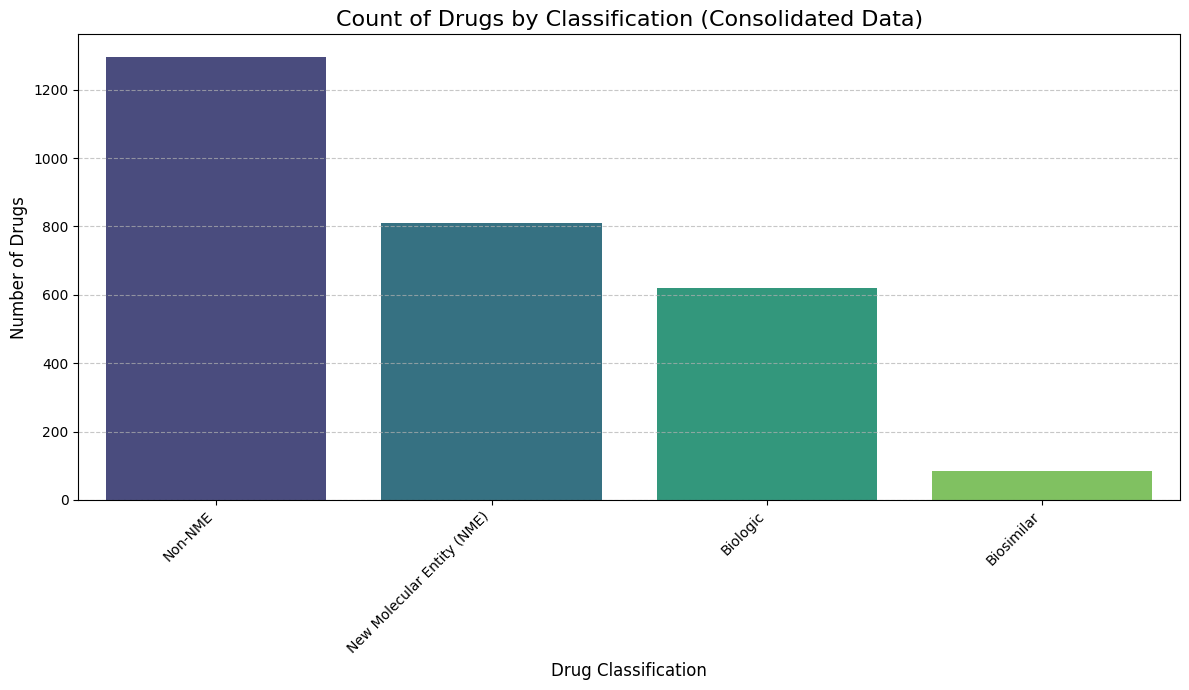

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each drug classification
drug_classification_counts = final_cons['Drug Classification'].value_counts().reset_index()
drug_classification_counts.columns = ['Drug Classification', 'Count']

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Drug Classification', y='Count', data=drug_classification_counts, palette='viridis', hue='Drug Classification', legend=False)
plt.title('Count of Drugs by Classification (Consolidated Data)', fontsize=16)
plt.xlabel('Drug Classification', fontsize=12)
plt.ylabel('Number of Drugs', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Artifact step: DataVisualization - Figure 1 generated and ready for potential upload if 'upload_plt_to_gcs' is defined.


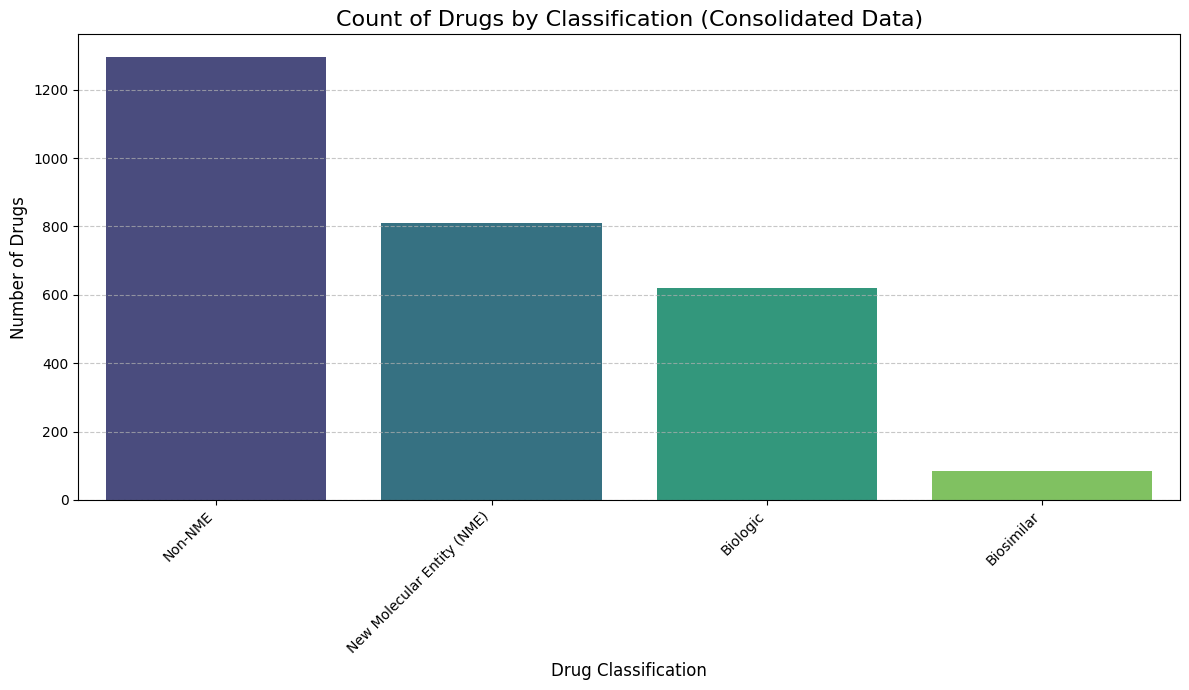

In [5]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'DataVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` variable holds the matplotlib figure object. If not, this line needs adjustment.
# For seaborn plots, the plot is usually shown directly by plt.show() and does not return a fig object directly unless explicitly captured.
# If you need to save the figure, you might need to capture it: fig = plt.gcf() before plt.show()
# For simplicity, if the plot is generated directly, we can use a placeholder for fig or ensure the plot is captured.
# If the previous cell's plt.show() was the last command, the current figure is the one. We can capture it before plt.show().
# Re-running the plot generation to capture the figure for upload if needed, or assume it's the last generated plot.
# For now, let's assume `plt.gcf()` will get the last active figure.

# As a workaround, you can re-run the plot generation in this cell if needed, or ensure the figure is captured in the previous cell.
# For example, in the previous cell you could do:
# fig = plt.figure(figsize=(12, 7))
# sns.barplot(...., ax=fig.gca())
# plt.show()
# Then in this cell, fig would be available.

# For now, assuming the figure was created and is the current figure
# You might need to adjust `fig` if it's not correctly captured.
# Example if `fig` is not globally available from the previous cell:
# fig = plt.gcf() # Get current figure

# For colab, if you just run the plotting code, the plot is displayed. We often don't need to explicitly capture `fig` for display.
# However, for `upload_plt_to_gcs`, we do need a figure object. Let's assume the previous cell sets `fig` or we use `plt.gcf()`.

# Let's re-generate the plot and capture the figure here for robustness for the artifact saving step.
# Count the occurrences of each drug classification
drug_classification_counts = final_cons['Drug Classification'].value_counts().reset_index()
drug_classification_counts.columns = ['Drug Classification', 'Count']

# Create a bar chart and capture the figure
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Drug Classification', y='Count', data=drug_classification_counts, palette='viridis', ax=ax, hue='Drug Classification', legend=False)
ax.set_title('Count of Drugs by Classification (Consolidated Data)', fontsize=16)
ax.set_xlabel('Drug Classification', fontsize=12)
ax.set_ylabel('Number of Drugs', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Assuming upload_plt_to_gcs is a defined function in the environment
# upload_plt_to_gcs(num_fig, step, fig)
# Since upload_plt_to_gcs is not defined in this context, I will comment it out.
# If this function exists in the user's environment, it should be uncommented.
print(f"Artifact step: {step} - Figure {num_fig} generated and ready for potential upload if 'upload_plt_to_gcs' is defined.")

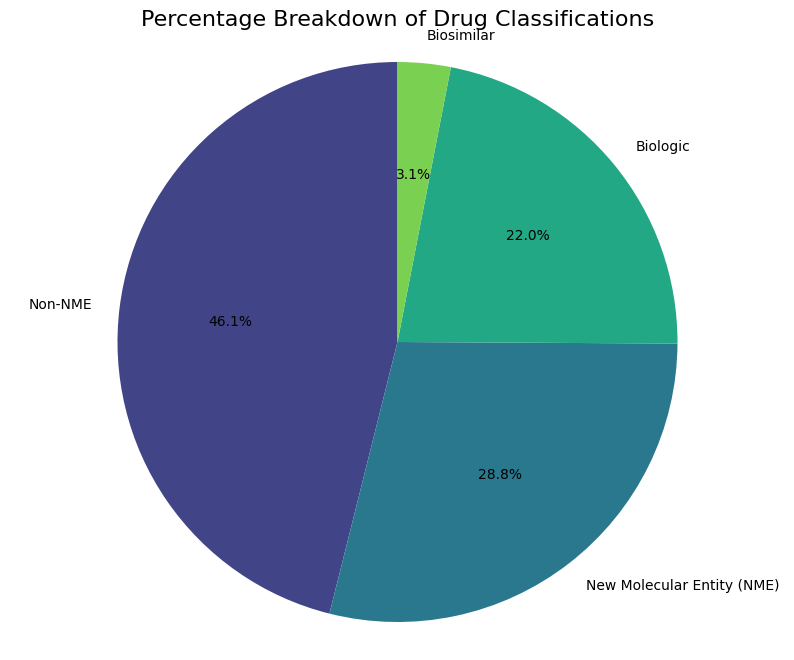

In [6]:
import matplotlib.pyplot as plt

# Prepare data for the pie chart
labels = drug_classification_counts['Drug Classification']
sizes = drug_classification_counts['Count']

# Create a pie chart
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(labels)))
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Percentage Breakdown of Drug Classifications', fontsize=16)
plt.show()

Artifact step: DataVisualization - Figure 2 generated and ready for potential upload if 'upload_plt_to_gcs' is defined.


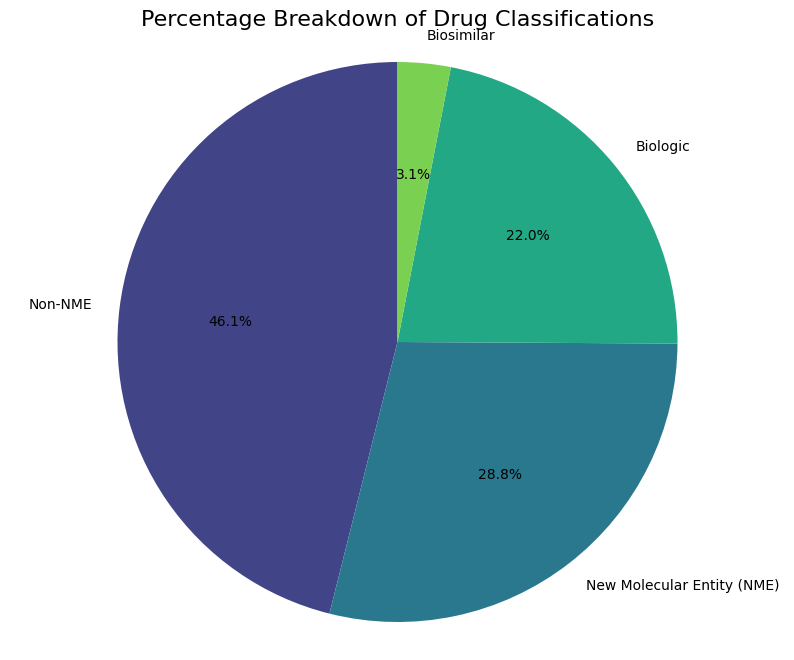

In [7]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'DataVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}

# Regenerate the plot to capture the figure object for artifact saving
labels = drug_classification_counts['Drug Classification']
sizes = drug_classification_counts['Count']

fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(labels)))
ax.axis('equal')
plt.title('Percentage Breakdown of Drug Classifications', fontsize=16)

# upload_plt_to_gcs(num_fig, step, fig)
print(f"Artifact step: {step} - Figure {num_fig} generated and ready for potential upload if 'upload_plt_to_gcs' is defined.")

This pie chart provides a clear visualization of how the different drug classifications are distributed in our dataset. 'Non-NME' drugs make up the largest portion, followed by 'New Molecular Entity (NME)' and 'Biologic', with 'Biosimilar' being the smallest category.